# SDOCX Format — Ink Properties

Each stroke's delta data blob contains more than just coordinates. After the coordinate
deltas, there's a **trailing section** with per-point attribute channels (pressure,
timestamp, tilt) and per-stroke properties (color, pen width).

This notebook decodes all of it and produces a full-fidelity rendering.

In [20]:
from pathlib import Path

SAMPLE_HANDWRITTEN = Path("../samples/handwritten.sdocx")
SAMPLE_MEDIA = Path("../samples/quiz.sdocx")

In [21]:
import zipfile
import struct
import numpy as np
import matplotlib.pyplot as plt

In [22]:
DELTA_SCALE = 1 / 32.0
COLOR_MARKER = b"\x02\x00\x01\x00\x00\x00"
MAX_PRESSURE = 1400.0

In [23]:
def load_page(path):
    """Load the first .page file and background color from an sdocx archive."""
    with zipfile.ZipFile(path) as z:
        page_key = [i.filename for i in z.infolist() if i.filename.endswith(".page")][0]
        page_data = z.read(page_key)

        bg_color = "#252525"
        if "note.note" in z.namelist():
            note = z.read("note.note")
            for i in range(len(note) - 12):
                if (
                    note[i] == 0x18
                    and note[i + 1] == 0x00
                    and note[i + 2 : i + 8] == b"\x00\x00\x01\x00\x00\x00"
                    and note[i + 11] == 0xFF
                ):
                    r, g, b = note[i + 8], note[i + 9], note[i + 10]
                    bg_color = f"#{r:02x}{g:02x}{b:02x}"
                    break

        return page_key, page_data, bg_color


page_key, page, bg_color = load_page(SAMPLE_HANDWRITTEN)
print(f"Page: {len(page):,} bytes")
print(f"Background: {bg_color}")

Page: 4,487,877 bytes
Background: #252525


In [24]:
def parse_strokes(page):
    """Parse all strokes from a .page file (same as notebook 02)."""
    base = struct.unpack_from("<I", page, 0)[0]
    stroke_count = struct.unpack_from("<I", page, base + 0x66)[0]
    strokes = []
    off = base + 0xB5
    for _ in range(stroke_count):
        if off + 89 > len(page):
            break
        bbox = struct.unpack_from("<4d", page, off)
        meta = page[off + 32 : off + 73]
        data_len = struct.unpack_from("<I", meta, 21)[0]
        sp_off = off + 73
        sx = struct.unpack_from("<d", page, sp_off)[0]
        sy = struct.unpack_from("<d", page, sp_off + 8)[0]
        data_off = sp_off + 16
        data_blob = page[data_off : data_off + data_len]

        x, y = sx, sy
        points = [(x, y)]
        i = 0
        while i + 3 < len(data_blob):
            dm, ds, ym, ys = (
                data_blob[i],
                data_blob[i + 1],
                data_blob[i + 2],
                data_blob[i + 3],
            )
            if ds not in (0x00, 0x80) or ys not in (0x00, 0x80):
                break
            dx = (dm if ds == 0x00 else -dm) * DELTA_SCALE
            dy = (ym if ys == 0x00 else -ym) * DELTA_SCALE
            x += dx
            y += dy
            points.append((x, y))
            i += 4

        strokes.append(
            {
                "bbox": bbox,
                "start": (sx, sy),
                "points": points,
                "data_blob": data_blob,
                "n_coord_bytes": i,
            }
        )
        off = data_off + data_len + 71
    return strokes


strokes = parse_strokes(page)
print(f"Parsed {len(strokes)} strokes")

Parsed 2769 strokes


---

## Trailing Data Structure

Each stroke's data blob has two regions:

```
+------------------------+----------------------------------------------+
|   Coordinate Deltas    |  Trailing: channels + stroke properties      |
|   (4 bytes per point)  |  [4B gap] [pressure] [time] [tilt] [color+w] |
+------------------------+----------------------------------------------+
```

The trailing section starts **4 bytes** after the coordinate data ends. It contains
**four per-point channels**, each encoded as sign-magnitude byte pairs (same encoding
as coordinates, but 1D — no x/y interleaving), followed by **per-stroke color and pen
width** at the very end.

In [25]:
s = strokes[0]
blob = s["data_blob"]
nc = s["n_coord_bytes"]
n_pts = len(s["points"]) - 1  # delta count (excludes start point)

print(f"Stroke 0: {len(s['points'])} points, {len(blob)} data bytes")
print(f"  Coordinate data:   {nc} bytes")
print(f"  Trailing data:     {len(blob) - nc} bytes")
print(f"  Delta points:      {n_pts}")
print(f"  Per-channel size:  {n_pts * 2} bytes")
print(f"  4 channels + gap:  {n_pts * 2 * 4 + 4} bytes")

Stroke 0: 204 points, 2518 data bytes
  Coordinate data:   812 bytes
  Trailing data:     1706 bytes
  Delta points:      203
  Per-channel size:  406 bytes
  4 channels + gap:  1628 bytes


In [26]:
def hexdump(data: bytes, offset: int = 0, limit: int = 0) -> str:
    lines = []
    n = len(data) if limit == 0 else min(len(data), limit)
    for i in range(0, n, 16):
        chunk = data[i : i + 16]
        hex_part = " ".join(f"{b:02x}" for b in chunk)
        ascii_part = "".join(chr(b) if 32 <= b < 127 else "\u00b7" for b in chunk)
        lines.append(f"  {offset + i:04x}  {hex_part:<48s} {ascii_part}")
    if limit and len(data) > limit:
        lines.append(f"  ... ({len(data) - limit} more bytes)")
    return "\n".join(lines)

In [27]:
print("Trailing data (first 64 bytes):")
print(hexdump(blob[nc:], limit=64))

Trailing data (first 64 bytes):
  0000  01 08 00 3a 00 00 00 00 00 00 01 00 00 00 02 00  ···:············
  0010  02 00 02 00 03 00 03 00 03 00 04 00 05 00 05 00  ················
  0020  05 00 00 00 06 00 07 00 07 00 07 00 00 00 08 00  ················
  0030  08 00 0a 00 09 00 00 00 0b 00 0b 00 0b 00 0d 00  ················
  ... (1642 more bytes)


---

## Per-Stroke Color

Color and pen width are stored at the **end** of the data blob, preceded by a 6-byte marker:

```
02 00 01 00 00 00
```

After the marker, there are two cases:

**With explicit color** (4th byte after marker = `0xFF`):
```
[02 00 01 00 00 00] [B] [G] [R] [FF] [f32 pen_width]
```
Color is **BGRA** (blue, green, red, alpha=0xFF).

**Default color** (4th byte != `0xFF`):
```
[02 00 01 00 00 00] [f32 pen_width]
```
Stroke uses the default ink color (white on dark backgrounds).

In [28]:
def extract_color_and_width(data_blob):
    """Extract per-stroke color and pen width from the trailing data.

    Returns (color_hex_or_None, pen_width).
    """
    color = None
    width = 0.8
    pos = data_blob.rfind(COLOR_MARKER)
    if pos < 0 or pos + 6 >= len(data_blob):
        return color, width

    after = data_blob[pos + 6 :]
    if len(after) >= 4 and after[3] == 0xFF:
        # BGRA color present
        b, g, r = after[0], after[1], after[2]
        color = f"#{r:02x}{g:02x}{b:02x}"
        if len(after) >= 8:
            width = struct.unpack("<f", after[4:8])[0]
    else:
        # No color \u2014 just pen width
        if len(after) >= 4:
            width = struct.unpack("<f", after[0:4])[0]

    return color, width

In [29]:
colors = {}
widths = []

for s in strokes:
    c, w = extract_color_and_width(s["data_blob"])
    s["color"] = c
    s["width"] = w
    key = c or "(default)"
    colors[key] = colors.get(key, 0) + 1
    widths.append(w)

print("Color distribution:\n")
for color, count in sorted(colors.items(), key=lambda x: -x[1]):
    print(f"  {color:<12} {count:>5} strokes")

Color distribution:

  (default)     2682 strokes
  #f7ba00         58 strokes
  #47a114         29 strokes


In [30]:
print(f"Pen width range: {min(widths):.2f} \u2013 {max(widths):.2f}")
print(f"Unique widths:   {sorted(set(f'{w:.2f}' for w in widths))}")

Pen width range: 5.54 – 9.12
Unique widths:   ['5.54', '5.94', '6.34', '7.53', '9.12']


---

## Per-Point Pressure

The first per-point channel encodes **pen pressure**. Like coordinates, it uses
sign-magnitude byte pairs — but these are **1D deltas** (not x/y pairs).

Each pair: `(magnitude, sign_flag)` where `0x00` = positive, `0x80` = negative.

The cumulative sum of pressure deltas gives the actual pressure at each point.
Values range from **0 to ~1400**, with a characteristic ramp-up at pen-down and
sharp drop at pen-lift.

In [31]:
def decode_sign_mag(data, offset, count):
    """Decode sign-magnitude byte pairs.

    Each pair: (magnitude, sign_flag)
        0x00 = positive (+magnitude)
        0x80 = negative (-magnitude)
    """
    vals = []
    for i in range(count):
        pos = offset + i * 2
        if pos + 1 >= len(data):
            break
        mag = data[pos]
        sign = data[pos + 1]
        vals.append(mag if sign == 0x00 else -mag)
    return vals


def decode_pressure(data_blob, n_coord_bytes, n_points):
    """Decode the pressure channel (channel 0) from trailing data."""
    trail_offset = n_coord_bytes + 4  # 4-byte gap after coordinates
    if trail_offset + n_points * 2 > len(data_blob):
        return []
    deltas = decode_sign_mag(data_blob, trail_offset, n_points)
    cumsum = 0
    pressures = []
    for d in deltas:
        cumsum += d
        pressures.append(cumsum)
    return pressures

In [32]:
for s in strokes:
    n_pts = len(s["points"]) - 1
    s["pressures"] = decode_pressure(s["data_blob"], s["n_coord_bytes"], n_pts)

has_pressure = sum(1 for s in strokes if s["pressures"])
print(f"Strokes with pressure data: {has_pressure} / {len(strokes)}")

Strokes with pressure data: 2769 / 2769


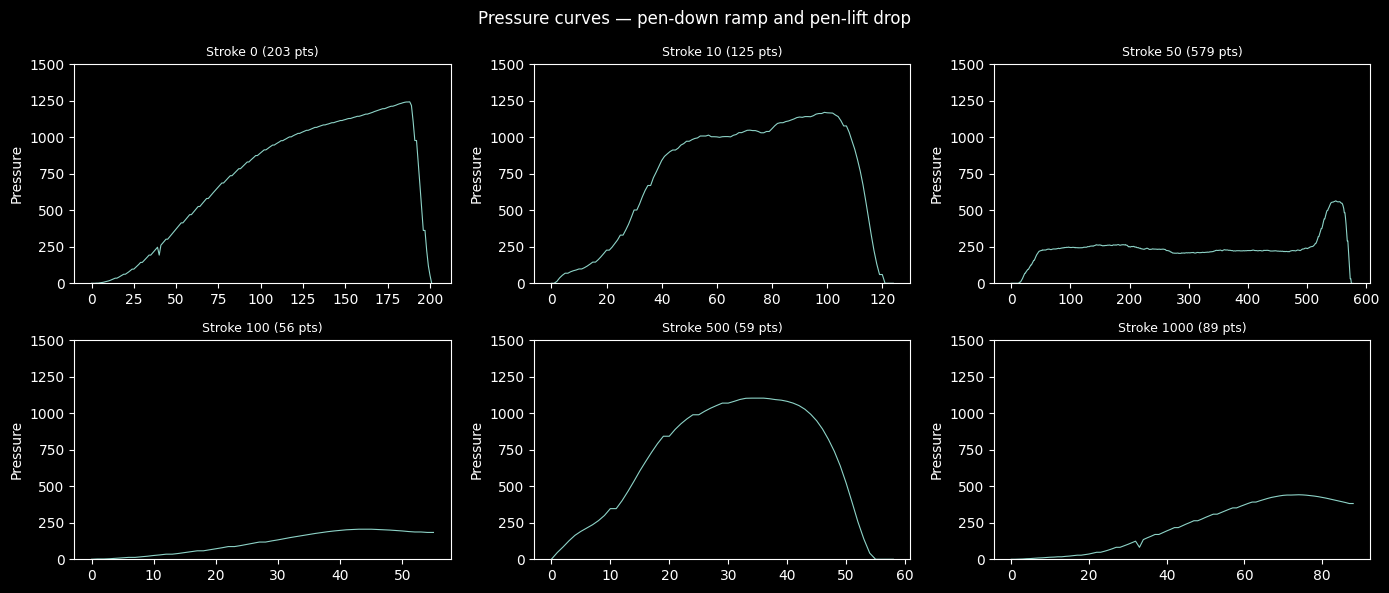

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for ax, idx in zip(axes.flat, [0, 10, 50, 100, 500, 1000]):
    if idx < len(strokes) and strokes[idx]["pressures"]:
        p = strokes[idx]["pressures"]
        ax.plot(p, linewidth=0.8)
        ax.set_title(f"Stroke {idx} ({len(p)} pts)", fontsize=9)
        ax.set_ylabel("Pressure")
        ax.set_ylim(0, 1500)

fig.suptitle(
    "Pressure curves \u2014 pen-down ramp and pen-lift drop",
    fontsize=12,
)
plt.tight_layout()
plt.show()

---

## All Per-Point Channels

After the 4-byte gap, there are **four consecutive channels**, each with `n_points`
sign-magnitude delta pairs:

| Channel | Offset from trail start | Content |
|---------|------------------------|---------|
| 0 | `0` | Pressure (0–1400) |
| 1 | `n_points x 2` | Timestamp (monotonic) |
| 2 | `n_points x 4` | Tilt X |
| 3 | `n_points x 6` | Tilt Y |

In [34]:
def decode_all_channels(data_blob, n_coord_bytes, n_points):
    """Decode all 4 per-point channels from trailing data."""
    trail_start = n_coord_bytes + 4
    channels = []
    for ch in range(4):
        ch_offset = trail_start + ch * n_points * 2
        if ch_offset + n_points * 2 > len(data_blob):
            channels.append([])
            continue
        deltas = decode_sign_mag(data_blob, ch_offset, n_points)
        cumsum = 0
        values = []
        for d in deltas:
            cumsum += d
            values.append(cumsum)
        channels.append(values)
    return channels

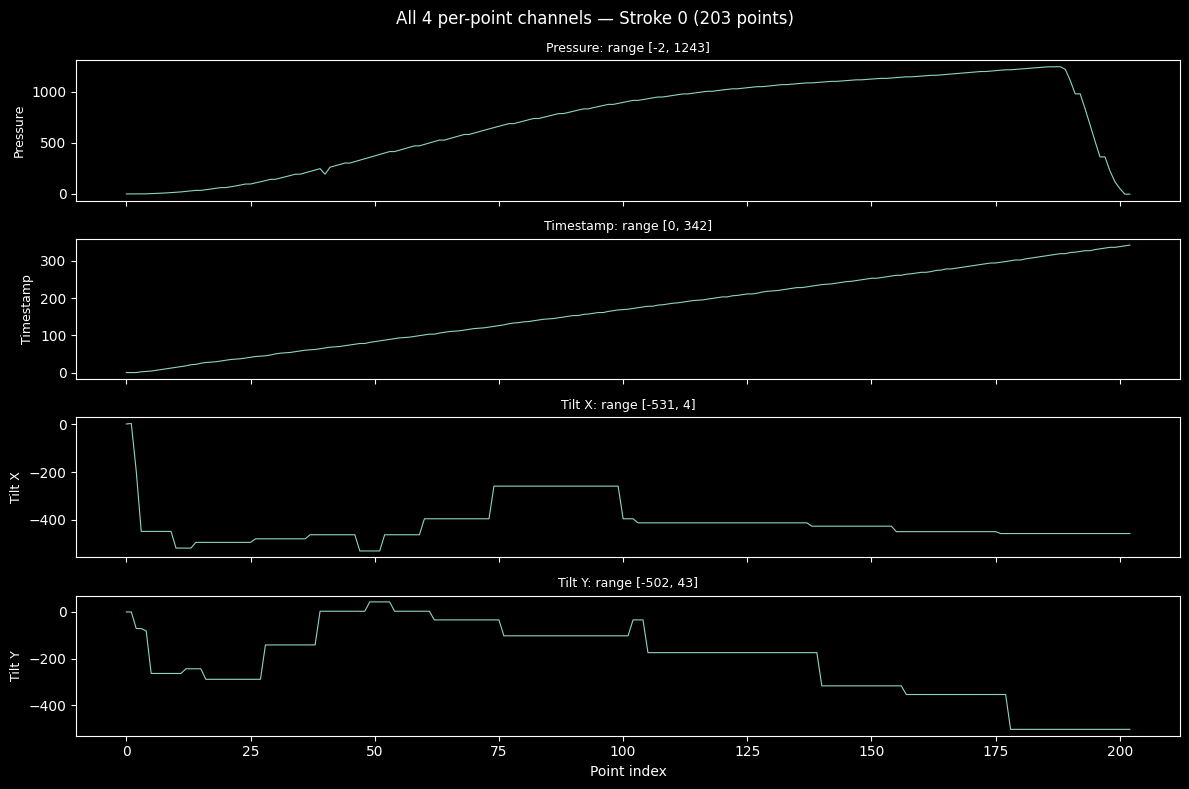

In [35]:
s = strokes[0]
n_pts = len(s["points"]) - 1
channels = decode_all_channels(s["data_blob"], s["n_coord_bytes"], n_pts)
ch_names = ["Pressure", "Timestamp", "Tilt X", "Tilt Y"]

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, ch, name in zip(axes, channels, ch_names):
    if ch:
        ax.plot(ch, linewidth=0.8)
        ax.set_ylabel(name, fontsize=9)
        ax.set_title(f"{name}: range [{min(ch)}, {max(ch)}]", fontsize=9)
axes[-1].set_xlabel("Point index")
fig.suptitle(
    f"All 4 per-point channels \u2014 Stroke 0 ({n_pts} points)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

---

## Full Rendering

Combining everything: coordinates from delta decoding, per-stroke color from the
color marker, and per-point pressure for variable stroke width.

Width formula:
```
base_width  = pen_width / 2.5
segment_width = base_width x (0.3 + 0.7 x normalized_pressure)
```

Where `normalized_pressure = clamp(cumulative_pressure / 1400, 0, 1)`.

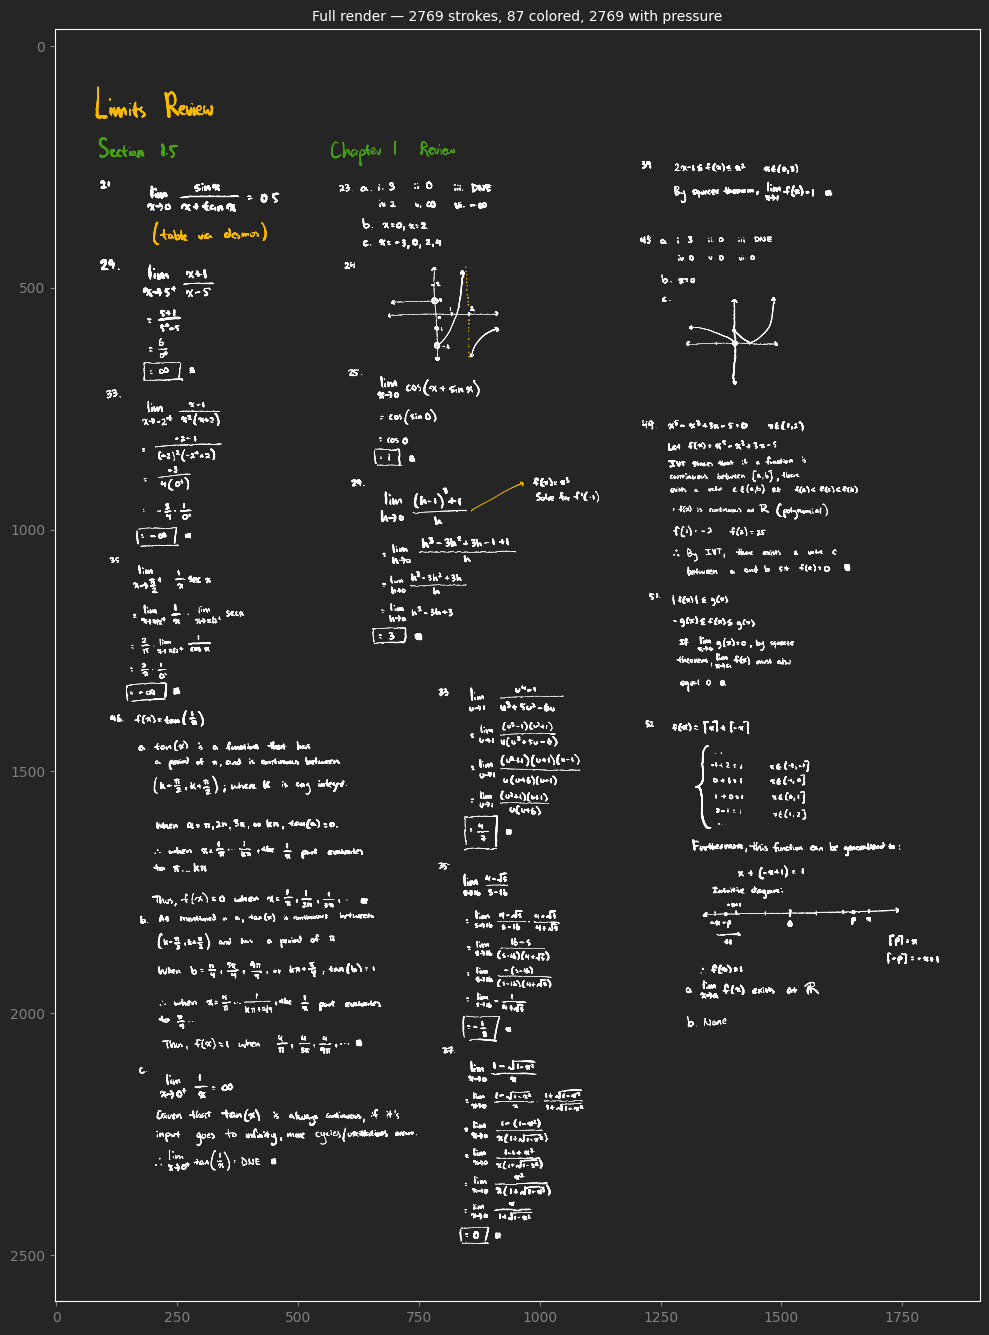

In [36]:
from matplotlib.collections import LineCollection

DEFAULT_INK = "#ffffff"

fig, ax = plt.subplots(figsize=(10, 14))
ax.set_facecolor(bg_color)
fig.patch.set_facecolor(bg_color)

for s in strokes:
    pts = s["points"]
    if len(pts) < 2:
        continue

    color = s.get("color") or DEFAULT_INK
    base_w = s.get("width", 0.8) / 4
    pressures = s.get("pressures", [])

    pts_arr = np.array(pts)
    segments = np.stack([pts_arr[:-1], pts_arr[1:]], axis=1)

    if len(pressures) >= len(pts) - 1:
        p_arr = np.array(pressures[: len(pts) - 1])
        p_norm = np.clip(p_arr / MAX_PRESSURE, 0, 1)
        widths = base_w * (0.3 + 0.7 * p_norm)
    else:
        widths = np.full(len(segments), base_w)

    lc = LineCollection(segments, linewidths=widths, colors=color, capstyle="round")
    ax.add_collection(lc)

ax.autoscale()
ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_title(
    f"Full render \u2014 {len(strokes)} strokes, "
    f"{sum(1 for s in strokes if s.get('color'))} colored, "
    f"{sum(1 for s in strokes if s.get('pressures'))} with pressure",
    color="white",
    fontsize=10,
)
ax.tick_params(colors="gray")
plt.tight_layout()
plt.show()

---

## Complete SDOCX Format Summary

### Container (ZIP)

| File | Content |
|------|---------|
| `end_tag.bin` | Timestamps (i64 ms epoch), `"Document for S-Pen SDK"` |
| `pageIdInfo.dat` | Page UUID (UTF-16LE) + 2 x 32-byte hashes |
| `media/mediaInfo.dat` | Media filename + SHA-256 + `EOFX` |
| `note.note` | Title, pen tools, background color, dimensions |
| `media/*.spi` | Page thumbnail (Samsung proprietary) |
| `<uuid>.page` | Stroke data (see below) |

### Page file (`.page`)

**Header:**

| Offset | Type | Field |
|--------|------|-------|
| `0x00` | u32 | Base offset (`base`) |
| `0x16` | u32 | Page width |
| `0x1A` | u32 | Page height |
| `0x26` | u16 | UUID length (chars) |
| `0x28` | UTF-16LE | Page UUID |
| `0x80` | 4 x f64 | Content bounding box |
| `base + 0x66` | u32 | Stroke count |

**Stroke records** (starting at `base + 0xB5`, sequential):

| Part | Bytes | Format |
|------|-------|--------|
| Bounding box | 32 | 4 x f64 |
| Metadata | 41 | byte 21: u32 data_len; byte 39: u16 n_points |
| Start point | 16 | 2 x f64 |
| Delta data | data_len | See below |
| Inter-stroke | 71 | UUID + timestamp |

**Delta data layout:**

| Region | Encoding | Description |
|--------|----------|-------------|
| Coordinates | 4-byte groups: `[dx_mag, dx_sign, dy_mag, dy_sign]` | `0x00`=+, `0x80`=-, scale x 1/32 |
| 4-byte gap | — | Separator |
| Pressure | 2-byte pairs x n_points | Sign-mag deltas, cumsum 0–1400 |
| Timestamp | 2-byte pairs x n_points | Sign-mag deltas, monotonic |
| Tilt X | 2-byte pairs x n_points | Sign-mag deltas |
| Tilt Y | 2-byte pairs x n_points | Sign-mag deltas |
| Color marker | `02 00 01 00 00 00` | Precedes color/width |
| Color (optional) | 4 bytes BGRA | Present if 4th byte = `0xFF` |
| Pen width | f32 | Follows color or marker directly |

**Footer:** 26-byte ASCII `"Page for SAMSUNG S-Pen SDK"`

### Base offset

The first u32 (`base`) determines where stroke fields are located. Simple handwritten
files have `base = 0xE3` (227). Files with embedded media (PDF, images) have a larger
base to accommodate object descriptor records in the header.

### Sign-magnitude encoding

Used for both coordinate deltas and per-point channels:
- Each value is a 2-byte pair: `(magnitude, sign_flag)`
- `sign_flag = 0x00`: positive (`+magnitude`)
- `sign_flag = 0x80`: negative (`-magnitude`)
- Bit 7 of the sign byte acts as the sign bit